# Convention symmetry check

Compares four internally consistent SrTiO3 interpolation conventions -- `mmn_pair`, `rdat_direct`, `rdat_pair`, `rfull_pair` (plus `rdat_pair_tau0`) -- and asserts `H(R)` and `A(R)` share an R-set before trusting any of them.

For every model, `Tr Omega_xy` is evaluated on: two paths in the undisplaced P+T-symmetric structure (zero everywhere), a path in each displaced structure's kx=1/2 mirror plane (zero everywhere), and a generic displaced path `k=(t, 0.30, 0.15)` whose intersections with mirror planes at t=0, 0.3, 0.5, 0.7, 1 are symmetry-enforced zeros.

Set `RUN_COMPUTATION = False` to load the last saved run from `results/convention_symmetry/` instead of rebuilding every model.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "validation").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from validation.symmetry.check_convention_symmetry_lib import (
    TRIALS,
    CONVENTIONS,
    OUTPUT_DIR,
    calculate,
    write_outputs,
    plot_conventions,
    load_results,
)

## Config

In [2]:
RUN_COMPUTATION = False  # True: rebuild every (trial, structure, convention) model. False: load results/convention_symmetry/.
N_POINTS = 201  # must be 10m+1 so every forced zero (t=0,0.3,0.5,0.7,1) lands on a sample
TRIALS_TO_RUN = list(TRIALS)  # subset of TRIALS keys, e.g. ["c", "sr_c"]
CONVENTIONS_TO_RUN = list(CONVENTIONS)  # subset of CONVENTIONS keys
OUTPUT_DIR = OUTPUT_DIR  # results/convention_symmetry

## Build every model and evaluate Tr Omega_xy on each path

`curves[(trial, structure, convention, path_name)]` is the traced-curvature array along that path -- inspect any entry directly. `provenance[(trial, structure, convention)]` carries the R-set/Hermiticity diagnostics per model.

In [3]:
if RUN_COMPUTATION:
    t, paths, curves, provenance = calculate(N_POINTS, TRIALS_TO_RUN, CONVENTIONS_TO_RUN)
    if not provenance:
        raise RuntimeError(
            "no (trial, convention) pair could be built: every requested combination "
            "is missing its inputs. rfull_pair needs a postw90 SrTiO3_r_full.dat next "
            "to the .chk of both structures."
        )
    len(curves), len(provenance)

a/base/mmn_pair


    SrTiO3.mmn absent; reusing AA_symmetry_a_base_182494bc889_wbnone_ws1em05.npz on its recorded provenance (staleness of the deleted input cannot be re-verified)


a/mode/mmn_pair


    SrTiO3.mmn absent; reusing AA_symmetry_a_mode_182499bc889_wbnone_ws1em05.npz on its recorded provenance (staleness of the deleted input cannot be re-verified)


a/base/rdat_direct


...

sr_c/mode/rfull_pair


sr_c/base/rdat_pair


sr_c/mode/rdat_pair


sr_c/base/rdat_pair_tau0


sr_c/mode/rdat_pair_tau0


## Save

In [4]:
if RUN_COMPUTATION:
    write_outputs(OUTPUT_DIR, t, paths, curves, provenance)

saved /Users/treycole/Repos/axion-phonon/validation/results/convention_symmetry/symmetry_curves.npz
saved /Users/treycole/Repos/axion-phonon/validation/results/convention_symmetry/symmetry_metrics.csv
saved /Users/treycole/Repos/axion-phonon/validation/results/convention_symmetry/berry_curvature_convention_comparison.png


## Load previously saved results (skip if you just computed above)

Only the curve arrays round-trip through `symmetry_curves.npz`; per-point provenance (R-set sizes, Hermiticity, forced-zero rows) lives in `symmetry_metrics.csv` -- open that directly for the full diagnostic table.

In [5]:
if not RUN_COMPUTATION:
    t, paths, curves = load_results(OUTPUT_DIR)

## Plot

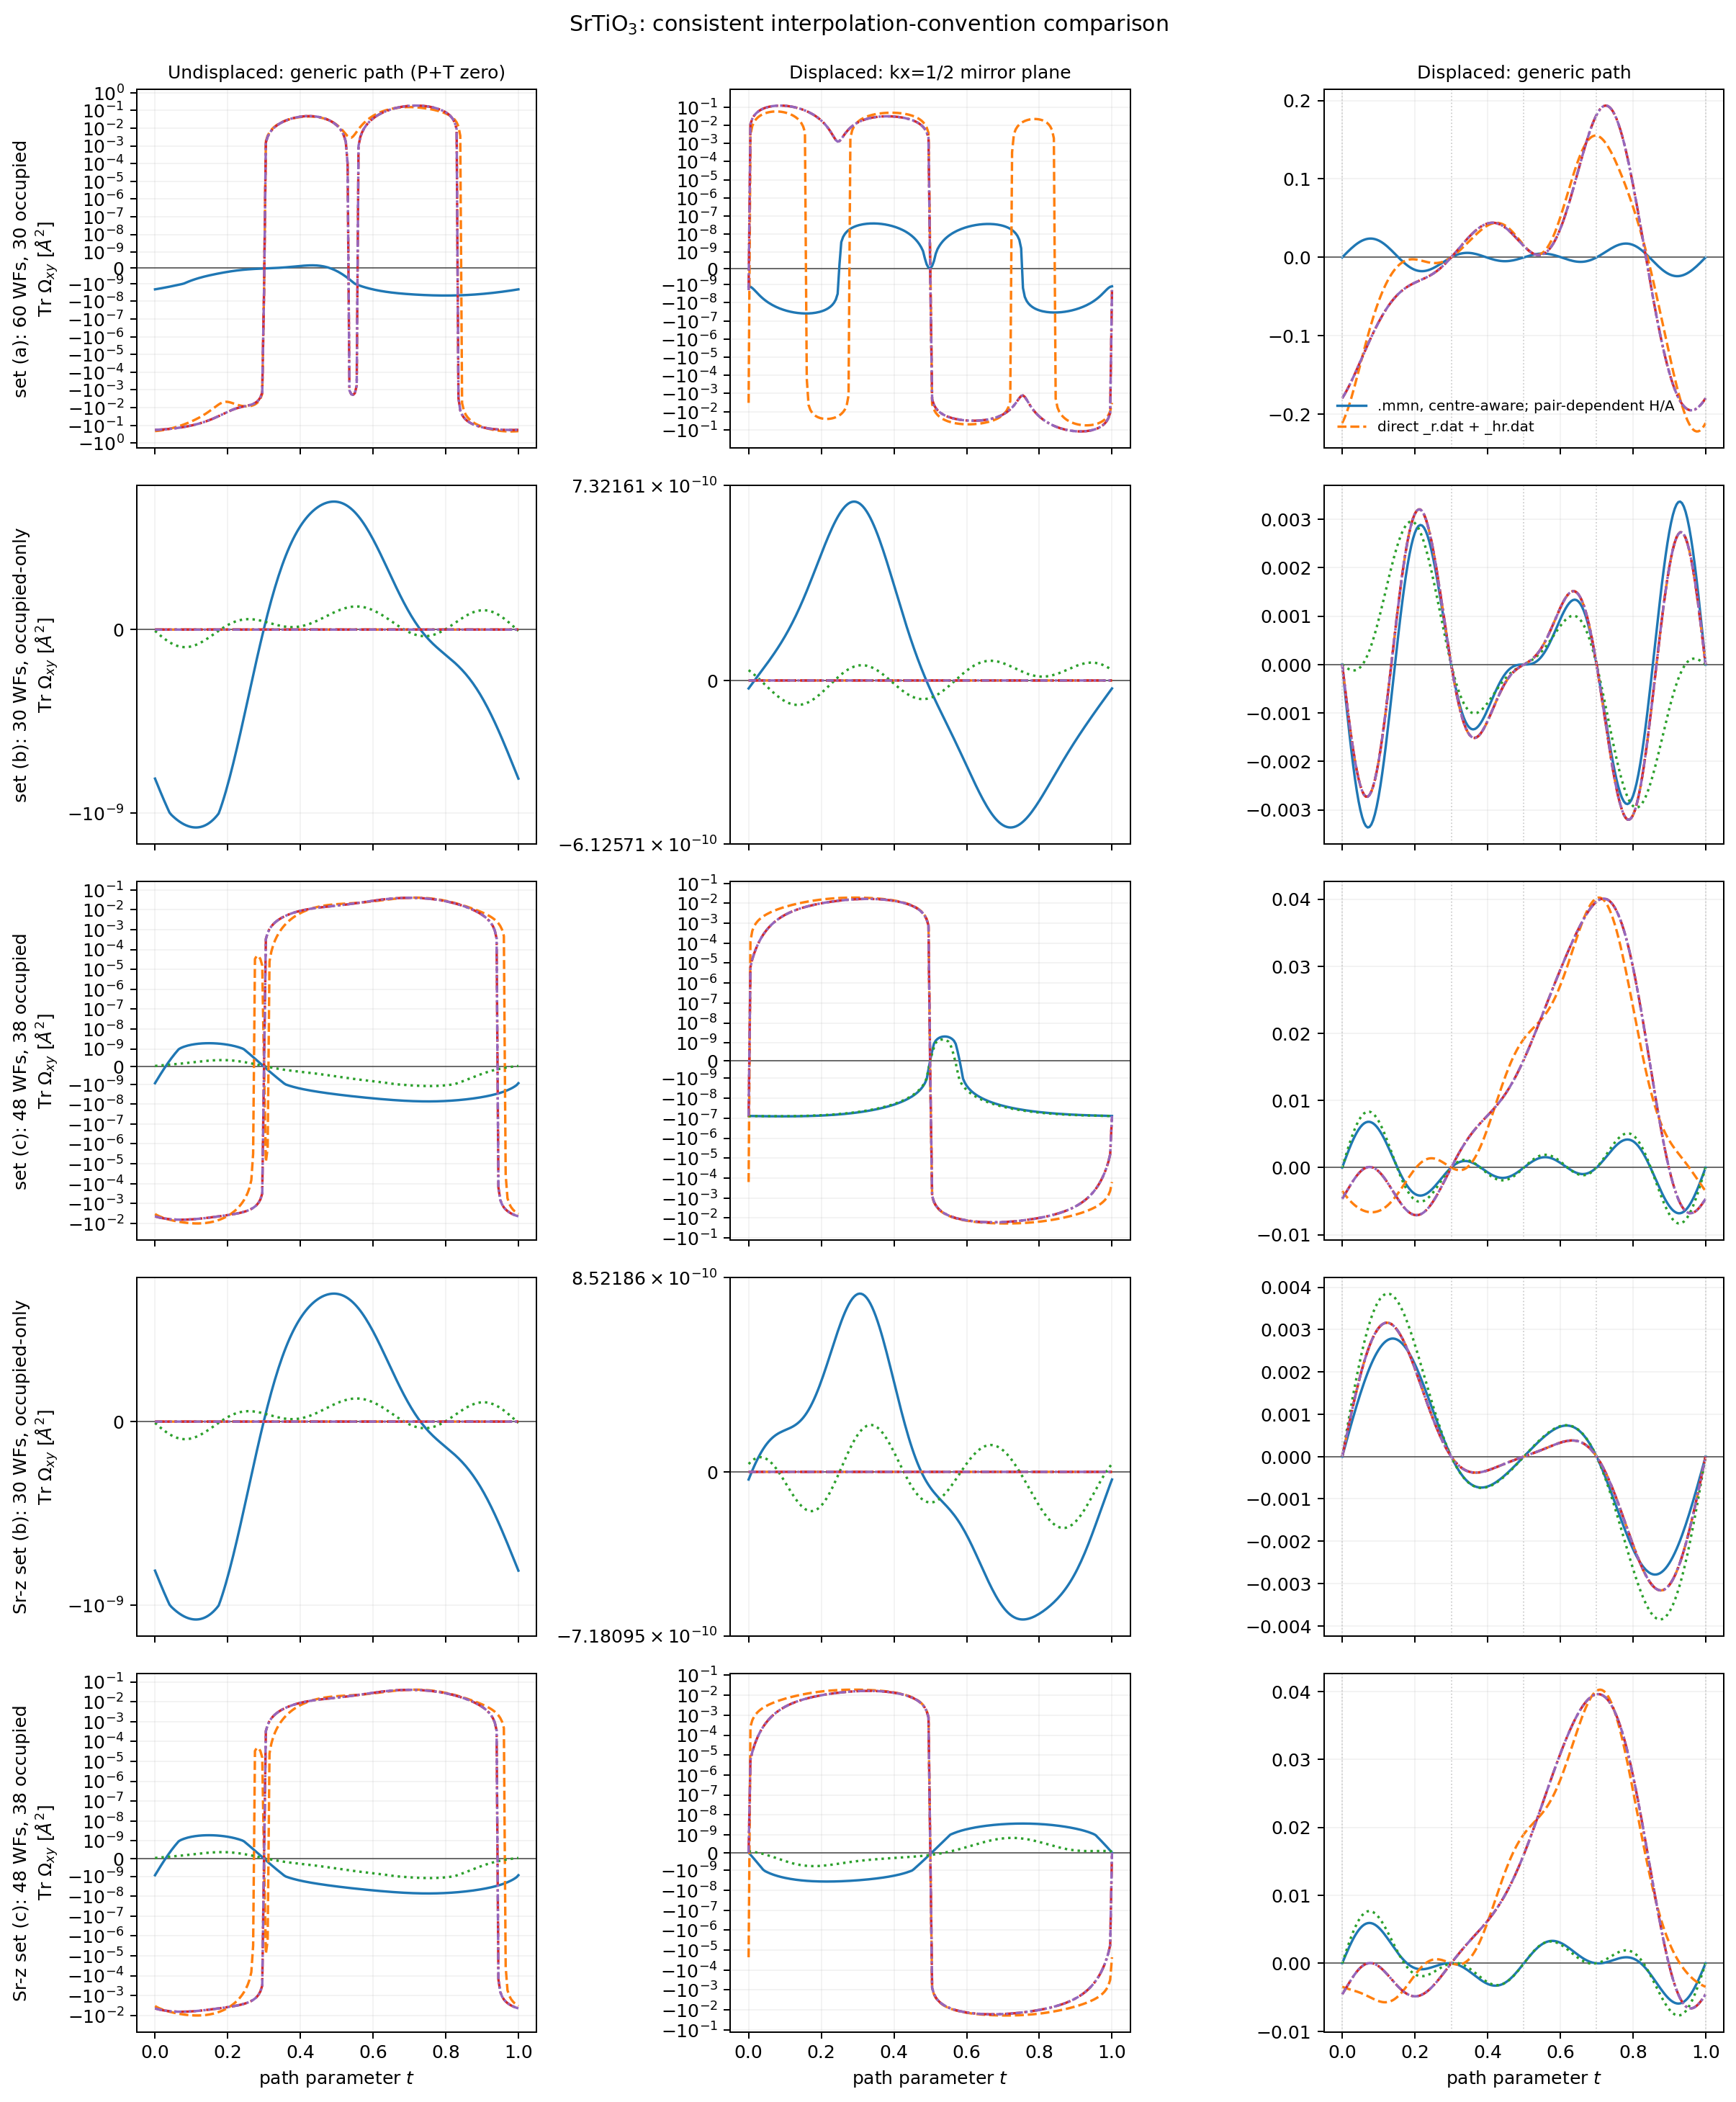

In [6]:
trials_done = sorted({key[0] for key in curves})
conventions_done = sorted({key[2] for key in curves}, key=list(CONVENTIONS).index)
fig = plot_conventions(t, curves, trials_done, conventions_done, TRIALS, CONVENTIONS)
plt.show()